In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os
from sklearn.metrics import classification_report
from PIL import Image
import gc
import matplotlib.pyplot as plt

In [2]:
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
tf.config.threading.set_intra_op_parallelism_threads(4)
tf.config.threading.set_inter_op_parallelism_threads(4)

In [3]:
train_dir = "./data/train"
test_dir = "./data/test"

In [4]:
IMG_SIZE = 64
BATCH_SIZE = 16
EPOCHS = 5

In [5]:
from pathlib import Path

def validate_and_clean_with_tensorflow(data_dir):
    """Remove images that TensorFlow cannot decode."""
    removed_files = []
    checked_count = 0
    
    print(f"\nValidating with TensorFlow: {data_dir}")
    
    # Get all image files
    image_extensions = ['.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp']
    all_files = []
    
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if any(file.lower().endswith(ext) for ext in image_extensions):
                all_files.append(os.path.join(root, file))
    
    print(f"Found {len(all_files)} image files to check")
    
    for file_path in all_files:
        try:
            # Try to load and decode exactly like TensorFlow does during training
            img_raw = tf.io.read_file(file_path)
            img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
            
            # Check if image has valid shape
            if len(img.shape) != 3 or img.shape[2] != 3:
                raise ValueError(f"Invalid shape: {img.shape}")
            
            checked_count += 1
            
            # Progress update
            if checked_count % 50 == 0:
                print(f"Validated {checked_count}/{len(all_files)} images...")
                
        except Exception as e:
            print(f"TensorFlow cannot decode: {os.path.basename(file_path)}")
            print(f"   Error: {str(e)[:80]}")
            try:
                os.remove(file_path)
                removed_files.append(file_path)
                print(f"   Removed successfully")
            except Exception as remove_error:
                print(f"   Could not remove: {remove_error}")
    
    print(f"\nTensorFlow validation complete!")
    print(f"  - Valid images: {checked_count}")
    print(f"  - Removed: {len(removed_files)}")
    
    return removed_files

In [6]:
# Clean the data
validate_and_clean_with_tensorflow(train_dir)
validate_and_clean_with_tensorflow(test_dir)


Validating with TensorFlow: ./data/train
Found 20000 image files to check
Validated 50/20000 images...
Validated 100/20000 images...
Validated 150/20000 images...
Validated 200/20000 images...
Validated 250/20000 images...
Validated 300/20000 images...
Validated 350/20000 images...
Validated 400/20000 images...
Validated 450/20000 images...
Validated 500/20000 images...
Validated 550/20000 images...
Validated 600/20000 images...
Validated 650/20000 images...
Validated 700/20000 images...
Validated 750/20000 images...
Validated 800/20000 images...
Validated 850/20000 images...
Validated 900/20000 images...
Validated 950/20000 images...
Validated 1000/20000 images...
Validated 1050/20000 images...
Validated 1100/20000 images...
Validated 1150/20000 images...
Validated 1200/20000 images...
Validated 1250/20000 images...
Validated 1300/20000 images...
Validated 1350/20000 images...
Validated 1400/20000 images...
Validated 1450/20000 images...
Validated 1500/20000 images...
Validated 1550/

[]

In [7]:
# load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("\nClasses found:", class_names)
print(f"Number of classes: {num_classes}")

Found 19993 files belonging to 5 classes.
Found 5057 files belonging to 5 classes.

Classes found: ['galaxy', 'nebula', 'planet', 'star', 'unknown']
Number of classes: 5


In [8]:
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

In [9]:
# Build models
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

C:\Users\samriti\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 171,429 (669.64 KB)

 Trainable params: 171,429 (669.64 KB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
# training
history = model.fit(
    train_ds, 
    validation_data=test_ds, 
    epochs=EPOCHS
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 77s 59ms/step - accuracy: 0.9302 - loss: 0.1897 - val_accuracy: 0.9171 - val_loss: 0.7800
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 24ms/step - accuracy: 0.9712 - loss: 0.0786 - val_accuracy: 0.9253 - val_loss: 0.8281
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.9785 - loss: 0.0625 - val_accuracy: 0.9308 - val_loss: 0.6824
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.9842 - loss: 0.0460 - val_accuracy: 0.9369 - val_loss: 1.2319
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.9887 - loss: 0.0339 - val_accuracy: 0.9357 - val_loss: 1.2784


In [11]:
# evaluation
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nBaseline Test Accuracy: {round(test_acc * 100, 2)}%")

317/317 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9357 - loss: 1.2784    

Baseline Test Accuracy: 93.57%


In [12]:
import numpy as np
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(pred_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Model Performance Summary:")

overall_acc = (y_true == y_pred).sum() / len(y_true)
print(f"\nOverall Accuracy: {overall_acc * 100:.2f}%")

print(f"\nTotal samples: {len(y_true)}")

for i, class_name in enumerate(class_names):
    # Get samples for this class
    true_mask = y_true == i
    num_samples = true_mask.sum()
    
    if num_samples > 0:
        # Calculate accuracy for this class
        correct = ((y_true == i) & (y_pred == i)).sum()
        accuracy = correct / num_samples * 100
        
        print(f"\n{class_name}:")
        print(f"  Samples: {num_samples}")
        print(f"  Correct: {correct}")
        print(f"  Accuracy: {accuracy:.2f}%")

model.summary()

gc.collect()

Model Performance Summary:

Overall Accuracy: 93.57%

Total samples: 5057

galaxy:
  Samples: 1000
  Correct: 998
  Accuracy: 99.80%

nebula:
  Samples: 1000
  Correct: 980
  Accuracy: 98.00%

planet:
  Samples: 1000
  Correct: 795
  Accuracy: 79.50%

star:
  Samples: 1057
  Correct: 993
  Accuracy: 93.95%

unknown:
  Samples: 1000
  Correct: 966
  Accuracy: 96.60%


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 514,289 (1.96 MB)

 Trainable params: 171,429 (669.64 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 342,860 (1.31 MB)

5100

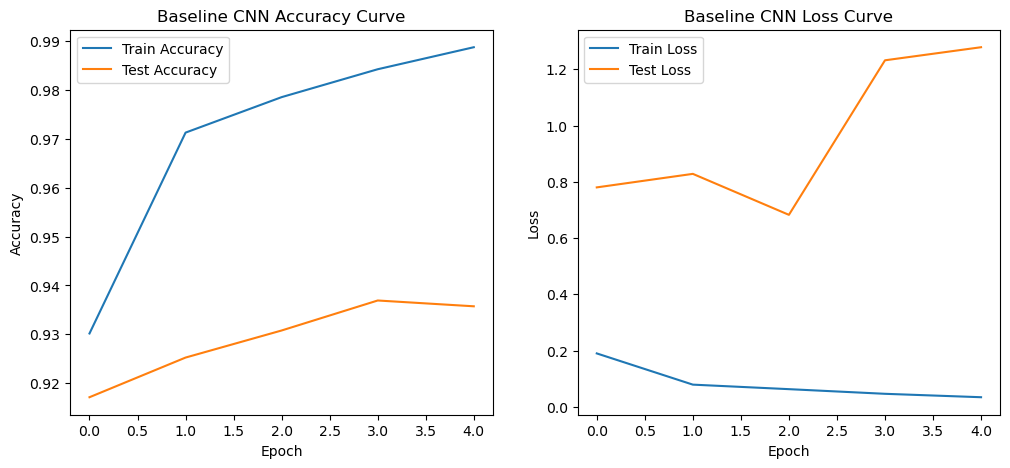

In [13]:
plt.figure(figsize=(12,5))

# Accuracy subplot
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Test Accuracy")
plt.title("Baseline CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss subplot
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Test Loss")
plt.title("Baseline CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [14]:
os.makedirs("results", exist_ok=True)

# Save a simpler report
with open("results/baseline_performance.txt", "w") as f:
    f.write("BASELINE MODEL PERFORMANCE\n")
    
    f.write(f"Test Accuracy: {round(test_acc * 100, 2)}%\n")
    f.write(f"Test Loss: {round(test_loss, 4)}\n\n")
    
    f.write("Classes:\n")
    for i, c in enumerate(class_names):
        f.write(f"  {i}: {c}\n")
    
    f.write("\n" + "=" * 60 + "\n")
    f.write("PER-CLASS PERFORMANCE\n")
    f.write("=" * 60 + "\n\n")
    
    # Manual per-class accuracy
    for i, class_name in enumerate(class_names):
        class_mask = y_true == i
        if class_mask.sum() > 0:
            correct = ((y_true == i) & (y_pred == i)).sum()
            total = class_mask.sum()
            accuracy = correct / total * 100
            f.write(f"{class_name}:\n")
            f.write(f"  Samples: {total}\n")
            f.write(f"  Correct: {correct}\n")
            f.write(f"  Accuracy: {accuracy:.2f}%\n\n")
    
    f.write("CONFIGURATION\n")
    f.write(f"Image Size: {IMG_SIZE}x{IMG_SIZE}\n")
    f.write(f"Batch Size: {BATCH_SIZE}\n")
    f.write(f"Epochs: {EPOCHS}\n")

print("Performance report saved")

# Save model
model.save("results/baseline_model.h5")
print("Model saved")

gc.collect()

Performance report saved
Model saved


7346